# Analise de precos de PS5

Notebook para conferir a base consolidada, validar tipos/nulos e comparar os precos coletados na Amazon e no Mercado Livre.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="colorblind")
pd.options.display.max_colwidth = 90

csv_path = Path("ps5_consolidado.csv")
historico_path = Path("historico_precos.csv")


def brl(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def encurtar(texto, tamanho=65):
    texto = str(texto)
    return texto if len(texto) <= tamanho else texto[:tamanho] + "..."


def preparar_base(caminho):
    dados = pd.read_csv(caminho)
    dados["coleta_em"] = pd.to_datetime(dados["coleta_em"], errors="coerce")
    dados["price_num"] = pd.to_numeric(dados["price_num"], errors="coerce")
    dados = dados.dropna(subset=["site", "title", "price_num", "url"])
    dados = dados.drop_duplicates(subset=["site", "title", "url", "price_num"])
    dados["title_curto"] = dados["title"].map(encurtar)
    return dados


df = preparar_base(csv_path)
df.head(10)

,coleta_em,site,title,price,price_num,url,title_curto
0,2026-06-05 15:23:27,Amazon,"Volante para jogos de Corrida Hori Apex para PS4, PS5 e PC Licenciado para consoles Sony","R$ 1.091,55",1091.55,https://www.amazon.com.br/sspa/click?ie=UTF8&spc=MTo4MDg5NDIxOTg5MTU1NDUyOjE3ODA2NzQyM...,"Volante para jogos de Corrida Hori Apex para PS4, PS5 e PC Licenc..."
1,2026-06-05 15:23:27,Amazon,"Combo Volante, Pedais e Cambio Logitech G29 SE Driving Force para PS5, PS4, PS3 e PC","R$ 2.299,90",2299.90,https://www.amazon.com.br/sspa/click?ie=UTF8&spc=MTo4MDg5NDIxOTg5MTU1NDUyOjE3ODA2NzQyM...,"Combo Volante, Pedais e Cambio Logitech G29 SE Driving Force para..."
2,2026-06-05 15:23:27,Amazon,Sony Control Inalámbrico PS5 DualSense Midnight Black,"R$ 379,00",379.00,https://www.amazon.com.br/sspa/click?ie=UTF8&spc=MTo4MDg5NDIxOTg5MTU1NDUyOjE3ODA2NzQyM...,Sony Control Inalámbrico PS5 DualSense Midnight Black
3,2026-06-05 15:23:27,Amazon,"Volante Logitech G PRO WHEEL Com Direct Drive 11 Nm, Feedback TRUEFORCE, Ultrarrealist...","R$ 8.499,15",8499.15,https://www.amazon.com.br/sspa/click?ie=UTF8&spc=MTo4MDg5NDIxOTg5MTU1NDUyOjE3ODA2NzQyM...,"Volante Logitech G PRO WHEEL Com Direct Drive 11 Nm, Feedback TRU..."
4,2026-06-05 15:23:27,Amazon,PlayStation 5 Edição Digital 825GB 1 Controle Branco Sony,"R$ 3.949,00",3949.00,https://www.amazon.com.br/PlayStation-Edi%C3%A7%C3%A3o-Digital-Controle-Sony/dp/B0GWNK...,PlayStation 5 Edição Digital 825GB 1 Controle Branco Sony
5,2026-06-05 15:23:27,Amazon,PlayStation 5 Slim Disk 1TB 1 Controle Branco Sony,"R$ 4.349,00",4349.00,https://www.amazon.com.br/PlayStation-Slim-Controle-Branco-Sony/dp/B0GWNFMG5L/ref=sr_1...,PlayStation 5 Slim Disk 1TB 1 Controle Branco Sony
6,2026-06-05 15:23:27,Amazon,Console PlayStation 5 - Digital Edition,"R$ 3.990,00",3990.00,https://www.amazon.com.br/Console-PlayStation-5-Digital-Edition/dp/B09FGCKBPK/ref=sr_1...,Console PlayStation 5 - Digital Edition
7,2026-06-05 15:23:27,Amazon,Console PS5 c/Drive Slim 1 TB c/ 1 Controle + EA FC 26,"R$ 4.699,90",4699.90,https://www.amazon.com.br/Console-PS5-Drive-Slim-Controle/dp/B0FPD9WL3X/ref=sr_1_11?di...,Console PS5 c/Drive Slim 1 TB c/ 1 Controle + EA FC 26
8,2026-06-05 15:23:27,Amazon,Sony PlayStation 5 Slim Digital Console 825GB - International Version,"R$ 4.099,90",4099.90,https://www.amazon.com.br/Sony-PlayStation-Digital-Console-825GB/dp/B0FTRYCKT1/ref=sr_...,Sony PlayStation 5 Slim Digital Console 825GB - International Ver...
9,2026-06-05 15:23:27,Amazon,Console PlayStation 5 - Digital Edition,"R$ 4.099,90",4099.90,https://www.amazon.com.br/Console-PlayStation-5-Digital-Edition/dp/B08CWG5K2D/ref=sr_1...,Console PlayStation 5 - Digital Edition


## Checagem inicial

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   coleta_em    88 non-null     datetime64[us]
 1   site         88 non-null     str           
 2   title        88 non-null     str           
 3   price        88 non-null     str           
 4   price_num    88 non-null     float64       
 5   url          88 non-null     str           
 6   title_curto  88 non-null     str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 4.9 KB


In [3]:
nulos = df.isna().sum().to_frame("nulos")
nulos["percentual"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos

,nulos,percentual
coleta_em,0,0.0
site,0,0.0
title,0,0.0
price,0,0.0
price_num,0,0.0
url,0,0.0
title_curto,0,0.0


In [4]:
resumo = pd.DataFrame(
    {
        "metrica": [
            "produtos",
            "sites",
            "menor_preco",
            "preco_medio",
            "maior_preco",
            "coleta_mais_recente",
        ],
        "valor": [
            len(df),
            df["site"].nunique(),
            brl(df["price_num"].min()),
            brl(df["price_num"].mean()),
            brl(df["price_num"].max()),
            df["coleta_em"].max(),
        ],
    }
)
resumo

,metrica,valor
0,produtos,88
1,sites,2
2,menor_preco,"R$ 28,90"
3,preco_medio,"R$ 3.240,92"
4,maior_preco,"R$ 8.499,15"
5,coleta_mais_recente,2026-06-05 15:23:27


## Estatisticas de preco

In [5]:
df["price_num"].describe().to_frame("preco")

,preco
count,88.000000
mean,3240.918182
std,2642.443023
min,28.900000
25%,290.945000
50%,4149.450000
75%,5159.750000
max,8499.150000


In [6]:
por_site = (
    df.groupby("site")
    .agg(
        produtos=("title", "count"),
        preco_medio=("price_num", "mean"),
        menor_preco=("price_num", "min"),
        maior_preco=("price_num", "max"),
    )
    .sort_values("preco_medio", ascending=False)
)

por_site_formatado = por_site.copy()
for coluna in ["preco_medio", "menor_preco", "maior_preco"]:
    por_site_formatado[coluna] = por_site_formatado[coluna].map(brl)

por_site_formatado

,produtos,preco_medio,menor_preco,maior_preco
site,,,,
Mercado Livre,39,"R$ 5.444,44","R$ 3.799,00","R$ 7.914,00"
Amazon,49,"R$ 1.487,10","R$ 28,90","R$ 8.499,15"


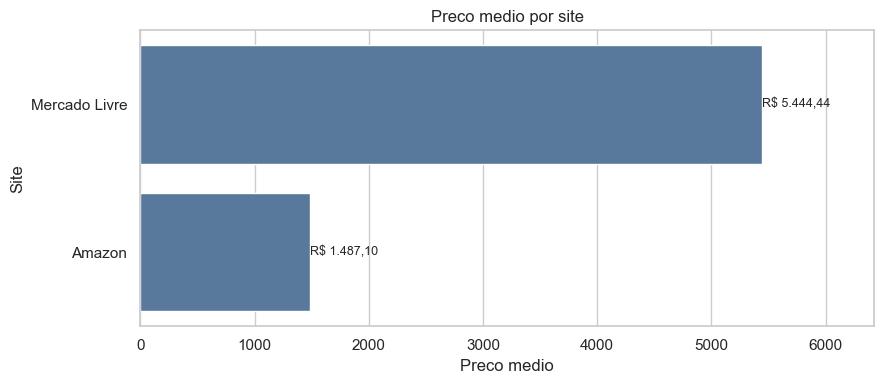

In [7]:
plt.figure(figsize=(9, 4))
media_site = por_site.reset_index()
ax = sns.barplot(
    data=media_site,
    x="preco_medio",
    y="site",
    color="#4C78A8",
    errorbar=None,
)
for valor, barra in zip(media_site["preco_medio"], ax.patches):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        brl(valor),
        va="center",
        ha="left",
        fontsize=9,
    )
plt.xlim(0, media_site["preco_medio"].max() * 1.18)
plt.title("Preco medio por site")
plt.xlabel("Preco medio")
plt.ylabel("Site")
plt.tight_layout()
plt.show()


## Rankings

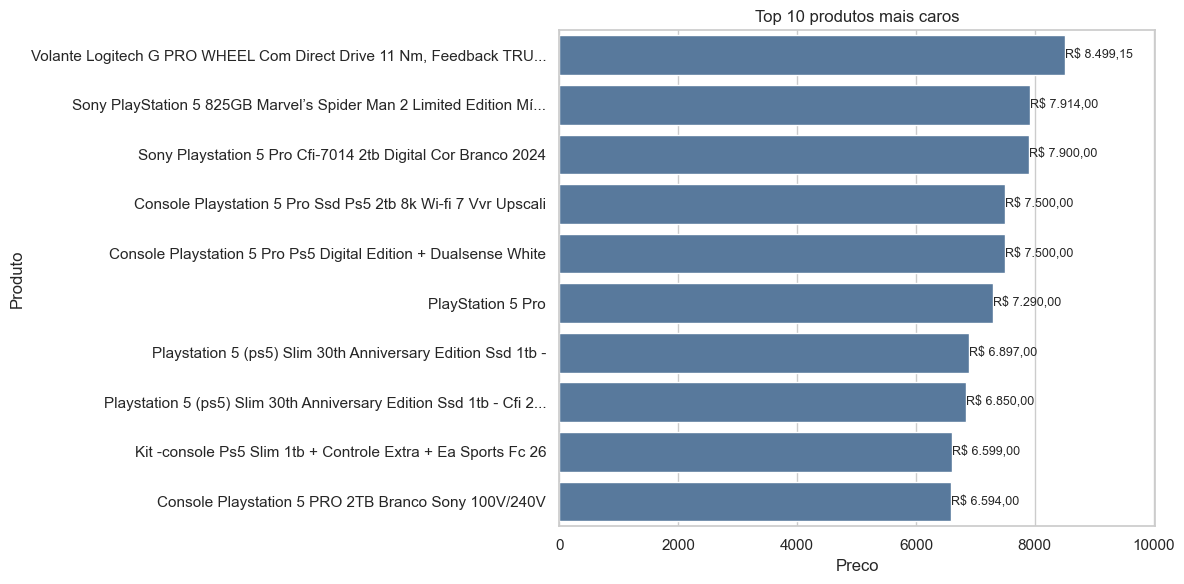

In [8]:
def grafico_ranking(dados, titulo):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=dados,
        x="price_num",
        y="title_curto",
        color="#4C78A8",
        errorbar=None,
    )
    for valor, barra in zip(dados["price_num"], ax.patches):
        ax.text(
            barra.get_width(),
            barra.get_y() + barra.get_height() / 2,
            brl(valor),
            va="center",
            ha="left",
            fontsize=9,
        )
    plt.xlim(0, dados["price_num"].max() * 1.18)
    plt.title(titulo)
    plt.xlabel("Preco")
    plt.ylabel("Produto")
    plt.tight_layout()
    plt.show()


top_caros = df.sort_values("price_num", ascending=False).head(10)
grafico_ranking(top_caros, "Top 10 produtos mais caros")


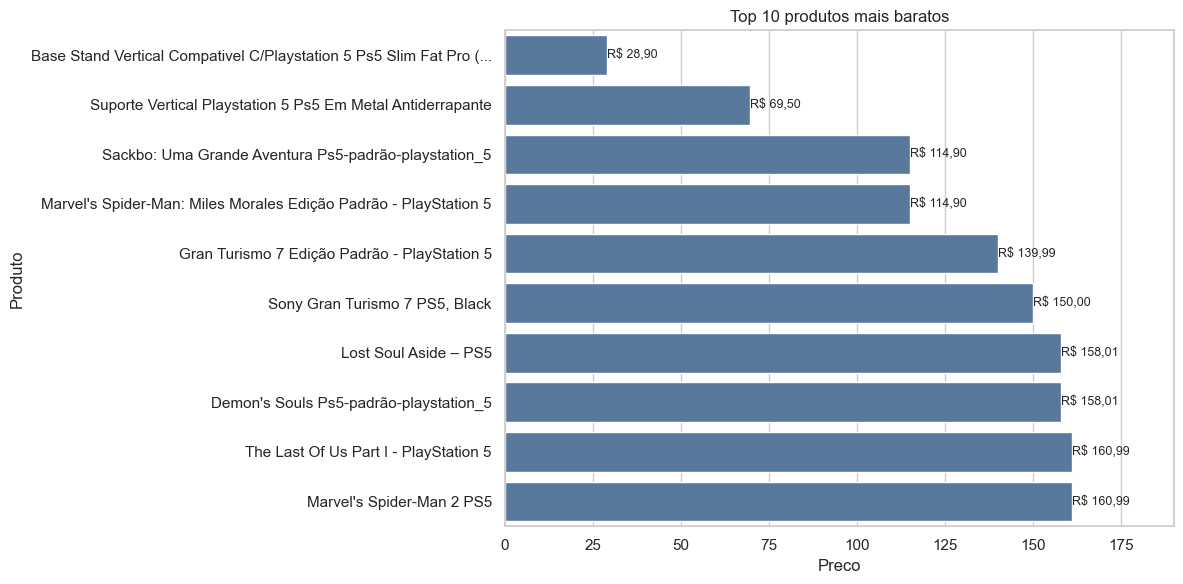

In [9]:
top_baratos = df.sort_values("price_num", ascending=True).head(10)
grafico_ranking(top_baratos, "Top 10 produtos mais baratos")

In [10]:
colunas_ranking = ["site", "title", "price", "price_num", "url"]
top_baratos[colunas_ranking]

,site,title,price,price_num,url
48,Amazon,Base Stand Vertical Compativel C/Playstation 5 Ps5 Slim Fat Pro (Branco),"R$ 28,90",28.90,https://www.amazon.com.br/sspa/click?ie=UTF8&spc=MTo4MDg5NDIxOTg5MTU1NDUyOjE3ODA2NzQyM...
46,Amazon,Suporte Vertical Playstation 5 Ps5 Em Metal Antiderrapante,"R$ 69,50",69.50,https://www.amazon.com.br/sspa/click?ie=UTF8&spc=MTo4MDg5NDIxOTg5MTU1NDUyOjE3ODA2NzQyM...
32,Amazon,Sackbo: Uma Grande Aventura Ps5-padrão-playstation_5,"R$ 114,90",114.90,https://www.amazon.com.br/Sackboy-Uma-Grande-Aventura-PlayStation/dp/B08QTSFCHX/ref=sr...
37,Amazon,Marvel's Spider-Man: Miles Morales Edição Padrão - PlayStation 5,"R$ 114,90",114.90,https://www.amazon.com.br/Marvels-Spider-Man-Miles-Morales-PlayStation/dp/B08QV3XK76/r...
44,Amazon,Gran Turismo 7 Edição Padrão - PlayStation 5,"R$ 139,99",139.99,https://www.amazon.com.br/Gran-Turismo-Edi%C3%A7%C3%A3o-Padr%C3%A3o-PlayStation/dp/B09...
21,Amazon,"Sony Gran Turismo 7 PS5, Black","R$ 150,00",150.00,https://www.amazon.com.br/Sony-Gran-Turismo-PS5-Black/dp/B09H2P828W/ref=sr_1_32?dib=ey...
30,Amazon,Lost Soul Aside – PS5,"R$ 158,01",158.01,https://www.amazon.com.br/PlayStation-Lost-Soul-Aside-PS5/dp/B0DX7HNLRM/ref=sr_1_41?di...
24,Amazon,Demon's Souls Ps5-padrão-playstation_5,"R$ 158,01",158.01,https://www.amazon.com.br/PlayStation-3006297-Demons-Souls-5/dp/B08QTLJDD2/ref=sr_1_35...
33,Amazon,The Last Of Us Part I - PlayStation 5,"R$ 160,99",160.99,https://www.amazon.com.br/Last-Us-Part-PlayStation/dp/B0B3YF2NZD/ref=sr_1_44?dib=eyJ2I...
23,Amazon,Marvel's Spider-Man 2 PS5,"R$ 160,99",160.99,https://www.amazon.com.br/Marvels-Spider-Man-Edi%C3%A7%C3%A3o-Standard-PlayStation/dp/...


## Distribuicao dos precos

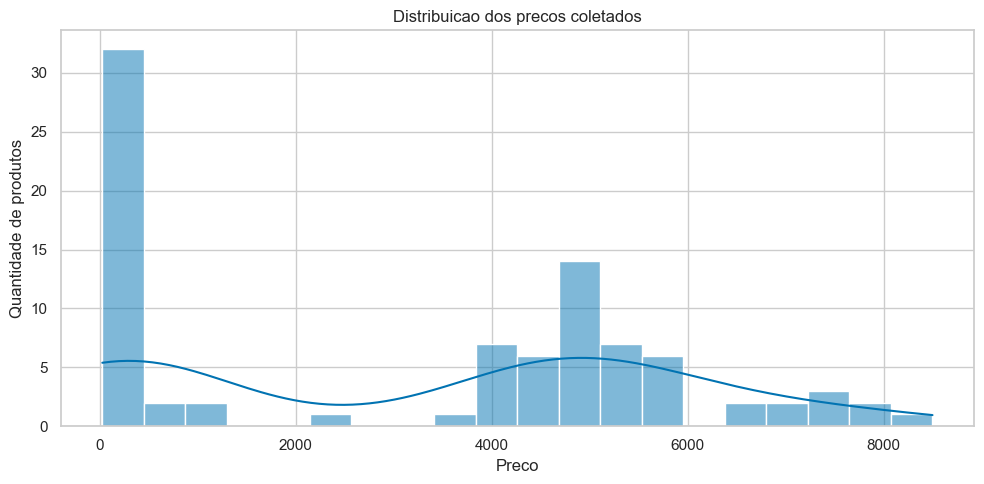

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price_num"], bins=20, kde=True)
plt.title("Distribuicao dos precos coletados")
plt.xlabel("Preco")
plt.ylabel("Quantidade de produtos")
plt.tight_layout()
plt.show()

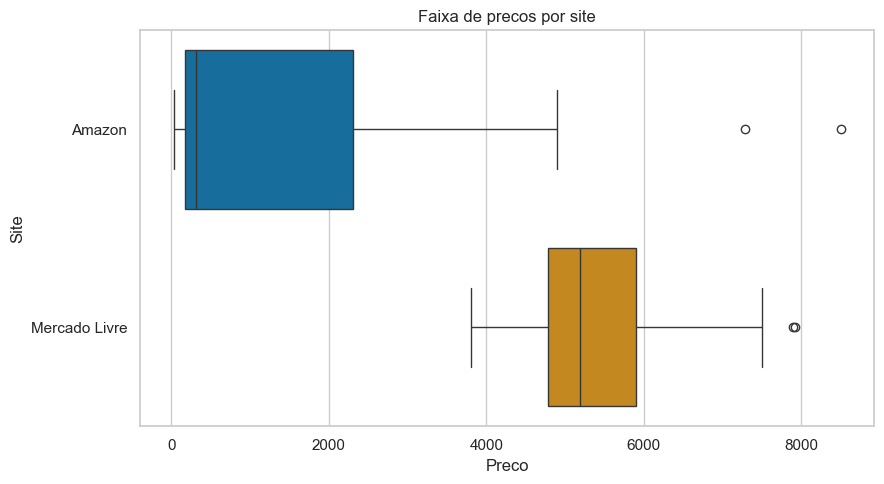

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="price_num", y="site", hue="site", legend=False)
plt.title("Faixa de precos por site")
plt.xlabel("Preco")
plt.ylabel("Site")
plt.tight_layout()
plt.show()

## Historico de coletas

In [13]:
if historico_path.exists():
    historico = pd.read_csv(historico_path)
    historico["coleta_em"] = pd.to_datetime(historico["coleta_em"], errors="coerce")
    historico["price_num"] = pd.to_numeric(historico["price_num"], errors="coerce")
    historico.head(10)
else:
    historico = pd.DataFrame()
    print("Ainda nao existe historico_precos.csv")

In [14]:
if not historico.empty:
    historico_resumo = (
        historico.groupby(["coleta_em", "site"])
        .agg(produtos=("title", "count"), preco_medio=("price_num", "mean"))
        .reset_index()
    )
    display(historico_resumo)

    if historico_resumo["coleta_em"].nunique() > 1:
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=historico_resumo, x="coleta_em", y="preco_medio", hue="site", marker="o")
        plt.title("Evolucao do preco medio por coleta")
        plt.xlabel("Data da coleta")
        plt.ylabel("Preco medio")
        plt.tight_layout()
        plt.show()
    else:
        print("Ainda existe apenas uma coleta. Rode main.py em outros dias para ver a evolucao.")

,coleta_em,site,produtos,preco_medio
0,2026-06-05 15:23:27,Amazon,49,1487.097959
1,2026-06-05 15:23:27,Mercado Livre,39,5444.435897


Ainda existe apenas uma coleta. Rode main.py em outros dias para ver a evolucao.
